In [1]:
!pip install kagglehub --break-system-packages

In [2]:
import kagglehub

# Download latest version
cache_path = kagglehub.dataset_download("harishkumardatalab/housing-price-prediction")

print("Path to dataset files:", cache_path)

Path to dataset files: /Users/swagat98/.cache/kagglehub/datasets/harishkumardatalab/housing-price-prediction/versions/1


In [3]:

import os 
import shutil


dataset_path = '/Users/swagat98/Proj_1/datasets'
dataset_name = input('Enter dataset name')


folder_path = f'{dataset_path}/{dataset_name}'

if not os.path.exists(folder_path):

    print(f"Creating directory {folder_path}")
    os.mkdir(folder_path)

else:
    print('Path already exists')


print(f"Copying main file from cache")
shutil.copytree(cache_path, folder_path, dirs_exist_ok=True)

Path already exists
Copying main file from cache


'/Users/swagat98/Proj_1/datasets/housing dataset'

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as py 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
df = pd.read_csv('/Users/swagat98/Proj_1/datasets/Housing price prediction/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
# label_names = input('Enter target column name: ')
label_cols = 'price'
target_index = df.columns.get_indexer_for([label_cols])[0]
y = df.iloc[:,target_index] # -> target


input_cols = df.columns.drop(label_cols) # input_col names
input_indices = df.columns.get_indexer_for(input_cols)
x = df.iloc[:, input_indices]





In [7]:
x.shape, y.shape

((545, 12), (545,))

In [8]:
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [9]:
columns = {'area':0, 'bedrooms':1, 'bathrooms':2, 'stories':3, 'mainroad':4, 'guestroom':5, 'basement':6, 'hotwaterheating':7, 'airconditioning':8, 'parking':9, 'prefarea':10,'furnishingstatus':11}

y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [10]:

fig2 = py.scatter(df, input_cols[0], label_cols,color='mainroad')
fig3 = py.scatter(df, input_cols[0], label_cols,color='guestroom')
fig4 = py.scatter(df, input_cols[0], label_cols,color='hotwaterheating')
fig5 = py.scatter(df, input_cols[0], label_cols,color='airconditioning')
fig6 = py.scatter(df, input_cols[0], label_cols,color='prefarea')
fig7 = py.scatter(df, input_cols[0], label_cols,color='furnishingstatus')

# fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()
fig6.show()
fig7.show()


In [11]:
columns

{'area': 0,
 'bedrooms': 1,
 'bathrooms': 2,
 'stories': 3,
 'mainroad': 4,
 'guestroom': 5,
 'basement': 6,
 'hotwaterheating': 7,
 'airconditioning': 8,
 'parking': 9,
 'prefarea': 10,
 'furnishingstatus': 11}

In [12]:
# no correlation with hotwatering


fig1 = py.scatter(df, input_cols[columns['stories']], label_cols,color='mainroad')
fig2 = py.scatter(df, input_cols[columns['stories']], label_cols,color='guestroom')
fig3 = py.scatter(df, input_cols[columns['stories']], label_cols,color='basement')
fig4 = py.scatter(df, input_cols[columns['stories']], label_cols,color='airconditioning')
# fig5 = py.scatter(df, input_cols[columns['stories']], label_cols,color='parking')
fig6 = py.scatter(df, input_cols[columns['stories']], label_cols,color='prefarea')
fig7 = py.scatter(df, input_cols[columns['stories']], label_cols,color='furnishingstatus')
fig1.show()
fig2.show()
fig3.show()
fig4.show()
# fig5.show()
fig6.show()
fig7.show()

In [13]:
import plotly.express as px

# 1. Define the columns you want on the X-axis
features = ['bedrooms', 'bathrooms', 'stories', 'parking']

# 2. "Melt" the data to stack these features into a single column
# This allows us to group them all at once
df_long = df.melt(
    id_vars=['price'],      # The value we want to average (Y-axis)
    value_vars=features,    # The categories (X-axis)
    var_name='Feature',     # Will contain 'bedrooms', 'stories', etc.
    value_name='Count'      # Will contain 1, 2, 3, 4...
)

# 3. Calculate the Average Price for each Feature + Count combination
df_avg = df_long.groupby(['Feature', 'Count'])['price'].mean().reset_index()

# 4. Create the Bar Charts with subplots (facet_col)
fig = px.bar(
    df_avg, 
    x='Count', 
    y='price', 
    color='Feature',        # Optional: distinct colors for each plot
    facet_col='Feature',    # Creates the side-by-side subplots
    facet_col_wrap=2,       # Arranges them in a 2x2 grid
    title="Average Price by Feature"
)

# Ensure the X-axis shows integers (1, 2, 3) cleanly
fig.update_xaxes(type='category') 
fig.show()

In [14]:
columns

{'area': 0,
 'bedrooms': 1,
 'bathrooms': 2,
 'stories': 3,
 'mainroad': 4,
 'guestroom': 5,
 'basement': 6,
 'hotwaterheating': 7,
 'airconditioning': 8,
 'parking': 9,
 'prefarea': 10,
 'furnishingstatus': 11}

In [15]:
# drop_cols = ['mainroad', 'hotwaterheating' ]
drop_cols = []
drop_col_indices = [columns[drop_cols] for drop_cols in drop_cols]
drop_col_indices

[]

In [16]:
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [17]:
# x = x.drop(columns=drop_cols)
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [18]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [19]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
dtypes: int64(5), object(7)
memory usage: 51.2+ KB


In [20]:
# Sort the object types and turn all to one hot encoded

obj_df = x.select_dtypes('object')
obj_df


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [21]:
# binary_df

binary_df = obj_df[['guestroom','basement','airconditioning','prefarea','mainroad','hotwaterheating']]
binary_df

,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating
0,no,no,yes,yes,yes,no
1,no,no,yes,no,yes,no
2,no,yes,no,yes,yes,no
3,no,yes,yes,yes,yes,no
4,yes,yes,yes,no,yes,no
...,...,...,...,...,...,...
540,no,yes,no,no,yes,no
541,no,no,no,no,no,no
542,no,no,no,no,yes,no
543,no,no,no,no,no,no


In [22]:
binary_df['basement'].unique()

array(['no', 'yes'], dtype=object)

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in binary_df.columns:
    binary_df[col] = le.fit_transform(binary_df[col])
# binary_df
binary_df

/var/folders/bq/t21x1lg144g_8csyzxfrxgt40000gn/T/ipykernel_81199/2604875371.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/bq/t21x1lg144g_8csyzxfrxgt40000gn/T/ipykernel_81199/2604875371.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/bq/t21x1lg144g_8csyzxfrxgt40000gn/T/ipykernel_81199/2604875371.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating
0,0,0,1,1,1,0
1,0,0,1,0,1,0
2,0,1,0,1,1,0
3,0,1,1,1,1,0
4,1,1,1,0,1,0
...,...,...,...,...,...,...
540,0,1,0,0,1,0
541,0,0,0,0,0,0
542,0,0,0,0,1,0
543,0,0,0,0,0,0


In [24]:
obj_df

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [25]:
obj_df = obj_df.drop(columns=binary_df.columns)
obj_df = pd.concat([obj_df, binary_df], axis=1)
obj_df

,furnishingstatus,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating
0,furnished,0,0,1,1,1,0
1,furnished,0,0,1,0,1,0
2,semi-furnished,0,1,0,1,1,0
3,furnished,0,1,1,1,1,0
4,furnished,1,1,1,0,1,0
...,...,...,...,...,...,...,...
540,unfurnished,0,1,0,0,1,0
541,semi-furnished,0,0,0,0,0,0
542,unfurnished,0,0,0,0,1,0
543,furnished,0,0,0,0,0,0


In [26]:
# obj_df.iloc[:,obj_df.columns.get_indexer_for(binary_df.columns)]

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# oe = OneHotEncoder(sparse_output=False,drop='first')
oe = LabelEncoder()

onehot_cols = ['furnishingstatus']

one_hot_df = obj_df[onehot_cols]

one_hot_df = oe.fit_transform(one_hot_df)
one_hot_df



/Users/swagat98/anaconda3/envs/machine-learning/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



array([0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1,
       0, 1, 0, 0, 2, 1, 2, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1,
       2, 0, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 1, 1,
       1, 2, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1,
       1, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 1, 1, 1, 2, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2,
       1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1,
       0, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 0, 1,

In [27]:
one_hot_df = pd.DataFrame(one_hot_df)


In [28]:
obj_df = obj_df.drop(columns=onehot_cols)
obj_df = pd.concat([obj_df, one_hot_df], axis=1)
obj_df

,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating,0
0,0,0,1,1,1,0,0
1,0,0,1,0,1,0,0
2,0,1,0,1,1,0,1
3,0,1,1,1,1,0,0
4,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...
540,0,1,0,0,1,0,2
541,0,0,0,0,0,0,1
542,0,0,0,0,1,0,2
543,0,0,0,0,0,0,0


In [29]:
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [30]:
obj_removed_df = x.drop(columns=x.select_dtypes('object').columns)
obj_removed_df


,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [31]:
x = pd.concat([obj_removed_df, obj_df], axis=1)
x

,area,bedrooms,bathrooms,stories,parking,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating,0
0,7420,4,2,3,2,0,0,1,1,1,0,0
1,8960,4,4,4,3,0,0,1,0,1,0,0
2,9960,3,2,2,2,0,1,0,1,1,0,1
3,7500,4,2,2,3,0,1,1,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,0,1,0,0,1,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,0,0,0,0,0,1,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [32]:
# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# sc = StandardScaler()
# mx = MinMaxScaler()



# sc_col = ['area']

# sc_df = x[sc_col]
# sc_df

# # sc_df = mx.fit_transform(sc_df)
# sc_df = pd.DataFrame(sc_df)
# sc_df


In [33]:
# x = x.drop(columns=sc_col)
# x = pd.concat([sc_df,x], axis=1)
# x

# Standardize y

In [34]:
# sc_y = StandardScaler()
# mx_y = MinMaxScaler()

# y = mx_y.fit_transform(pd.DataFrame(y))
# y = pd.DataFrame(y)
# y



In [35]:
x = x.rename(columns={0:'furnishingstatus'})
x

,area,bedrooms,bathrooms,stories,parking,guestroom,basement,airconditioning,prefarea,mainroad,hotwaterheating,furnishingstatus
0,7420,4,2,3,2,0,0,1,1,1,0,0
1,8960,4,4,4,3,0,0,1,0,1,0,0
2,9960,3,2,2,2,0,1,0,1,1,0,1
3,7500,4,2,2,3,0,1,1,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,0,1,0,0,1,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,0,0,0,0,0,1,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [36]:
# columns = {housing_price_prediction.ipynb}

In [37]:
# x_temp = x.iloc[:,9]
# x_drop = x.drop(columns=['mainroad'])

x = x[['area','bedrooms','bathrooms','stories','mainroad','guestroom','basement','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']]
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [38]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x = scaler.fit_transform(x)
y = scaler.fit_transform(y.values.reshape(-1, 1)) 

In [40]:
x

array([[0.39656357, 0.6       , 0.33333333, ..., 0.66666667, 1.        ,
        0.        ],
       [0.5024055 , 0.6       , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.57113402, 0.4       , 0.33333333, ..., 0.66666667, 1.        ,
        0.5       ],
       ...,
       [0.13539519, 0.2       , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.08659794, 0.4       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.15120275, 0.4       , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [41]:
y

array([[1.        ],
       [0.90909091],
       [0.90909091],
       [0.90606061],
       [0.83636364],
       [0.78787879],
       [0.72727273],
       [0.72727273],
       [0.7030303 ],
       [0.6969697 ],
       [0.6969697 ],
       [0.68666667],
       [0.65454545],
       [0.64848485],
       [0.64848485],
       [0.63636364],
       [0.63636364],
       [0.62424242],
       [0.61818182],
       [0.61515152],
       [0.60606061],
       [0.6       ],
       [0.5969697 ],
       [0.5969697 ],
       [0.59090909],
       [0.58787879],
       [0.58121212],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.56666667],
       [0.55757576],
       [0.55151515],
       [0.54813333],
       [0.54484848],
       [0.53939394],
       [0.53787879],
       [0.53333333],
       [0.53030303],
       [0.52727273],
       [0.51515152],
       [0.51515152],
       [0.5030303 ],
       [0.5030303 ],
       [0.5       ],
       [0.496

In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=50)

In [43]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(436, 12)
(436, 1)
(109, 12)
(109, 1)


In [44]:
# x_train.info()

x_train = np.asarray(x_train).astype('float32')
x_test = np.asarray(x_test).astype('float32')


In [45]:
x_train.shape

(436, 12)

In [63]:
import tensorflow as tf
import keras


model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(units=64,activation='relu'),
    tf.keras.layers.Dense(units=32,activation='relu'),
    tf.keras.layers.Dense(units=1,activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mse'])


In [64]:
x_train.shape

(436, 12)

In [65]:
x

array([[0.39656357, 0.6       , 0.33333333, ..., 0.66666667, 1.        ,
        0.        ],
       [0.5024055 , 0.6       , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.57113402, 0.4       , 0.33333333, ..., 0.66666667, 1.        ,
        0.5       ],
       ...,
       [0.13539519, 0.2       , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.08659794, 0.4       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.15120275, 0.4       , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [66]:
y

array([[1.        ],
       [0.90909091],
       [0.90909091],
       [0.90606061],
       [0.83636364],
       [0.78787879],
       [0.72727273],
       [0.72727273],
       [0.7030303 ],
       [0.6969697 ],
       [0.6969697 ],
       [0.68666667],
       [0.65454545],
       [0.64848485],
       [0.64848485],
       [0.63636364],
       [0.63636364],
       [0.62424242],
       [0.61818182],
       [0.61515152],
       [0.60606061],
       [0.6       ],
       [0.5969697 ],
       [0.5969697 ],
       [0.59090909],
       [0.58787879],
       [0.58121212],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.57575758],
       [0.56666667],
       [0.55757576],
       [0.55151515],
       [0.54813333],
       [0.54484848],
       [0.53939394],
       [0.53787879],
       [0.53333333],
       [0.53030303],
       [0.52727273],
       [0.51515152],
       [0.51515152],
       [0.5030303 ],
       [0.5030303 ],
       [0.5       ],
       [0.496

In [67]:
model_history = model.fit(x_train,y_train, batch_size=32, epochs=50)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0725 - mse: 0.0725  
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0246 - mse: 0.0246 
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0145 - mse: 0.0145 
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0125 - mse: 0.0125 
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0105 - mse: 0.0105 
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0099 - mse: 0.0099 
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0095 - mse: 0.0095 
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0092 - mse: 0.0092 
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - mse: 0.0089 
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - mse: 0.0086 
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0083 - mse: 0.0083 
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0081 - mse: 0.0081 
Epoch 13/50
14/14 ━━━━━━━━━━━━━━━━━━

In [68]:
history = model_history.history

In [69]:
len(history['loss'])

50

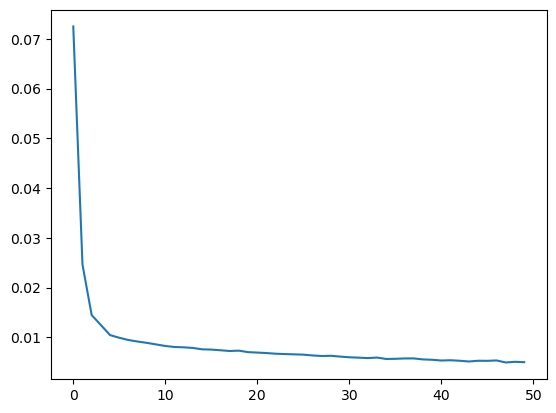

In [70]:
x_axis = np.arange(0,len(history['loss']))
len(x)
history['loss']
plt.plot(x_axis,history['loss'])

In [71]:
x_test.shape

(109, 12)

In [72]:

y_pred = model.predict(x_test)


from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
0.7273971208050081


In [73]:
from xgboost import XGBRegressor

In [74]:
xgb = XGBRegressor()

xgb_result = xgb.fit(x_train, y_train)
xgb_result

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [75]:
y_pred = xgb_result.predict(x_test)
y_pred


score = r2_score(y_test, y_pred)
print(score)

0.6997700867070136


In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(x_train,y_train)

/Users/swagat98/anaconda3/envs/machine-learning/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
y_pred = rf_model.predict(x_test)

In [79]:
rf_acc = r2_score(y_test, y_pred)
rf_acc

0.7397384535610716